In [1]:
import numpy as np
import netCDF4 as nc
import glob
import os
import json
import toml
from scipy.interpolate import PchipInterpolator

import matplotlib as mpl
font = {'family' : 'sans',
        'size'   : 12}

mpl.rc('font', **font)
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MultipleLocator, LogLocator, MaxNLocator
import matplotlib.pyplot as plt

import matplotlib.patheffects as pe

import pandas as pd
from cmcrameri import cm

# from proteus.utils.plot import _preset_colours, get_colour, latexify

# Astronomical constants
L_sun = 3.828e26  # W, IAU definition
R_sun = 6.957e8  # m
R_sun_cm = 100 * R_sun  # cm
M_sun = 1.988416e30  # kg
AU = 1.495978707e11  # m
AU_cm = AU * 100.0  # cm
M_earth = 5.972e24  # kg
R_earth = 6.335439e6  # m
R_core_earth = 3485000.0  # m
M_core_earth = 1.94e24  # kg
mol = 6.02214076e23  # mol definition


In [63]:
def get_bo_run(output_dir):

    # Read BO config file
    config_path = os.path.join(output_dir, "copy.infer.toml")
    infer_conf = toml.load(config_path)
    obs = infer_conf['observables']
    prs = infer_conf['parameters']

    # Extract log of BO run
    fpath = os.path.join(output_dir, "logs.csv")
    log = []
    best_obj = -np.inf
    with open(fpath, 'r') as f:
        for line in f.readlines():
            if '{' not in line:
                continue
            line = line.replace("'", '"').replace("None", "1.0")[1:-2]
            json_line = json.loads(line) # parse json into dict
            log.append(json_line)

            if json_line['y_value'] > best_obj:
                best_obj = json_line['y_value']

    # Mark best worker
    for run in log:
        run['is_best'] = run['y_value'] == best_obj

    # For each worker, read helpfile
    helps = []
    for run in log:
        wk = run['worker']
        id = run['task_id']
        help_path = os.path.join(output_dir, "workers", f"w_{wk}", f"i_{id}", "runtime_helpfile.csv")
        helps.append(pd.read_csv(help_path, delimiter=r"\s+"))

    # For each worker, read config
    confs = []
    for run in log:
        wk = run['worker']
        id = run['task_id']
        conf_path = os.path.join(output_dir, "workers", f"w_{wk}", f"i_{id}", "input.toml")
        confs.append(toml.load(conf_path))

    # Package into dict
    bo_run = {
        "config": infer_conf,
        "log": log,
        "helps": helps,
        "confs": confs,
        "obs": obs,
        "prs": prs,
    }
    return bo_run

bo_paths = output_dirs = (
    "data/bayesopt_infer_sn",
    "data/bayesopt_infer_se",
    "data/bayesopt_infer_tr",
)

bo_cols = ('tab:blue', 'tab:orange', 'tab:green')
bo_tits = ('Sub-Neptune', 'Super-Earth', 'Terrestrial')

bo_data = [get_bo_run(dir) for dir in bo_paths]

bo_truth = {
    "params.stop.time.maximum": [5e8, 2e9, 8e8]
}


Observables: ['M_planet', 'R_obs', 'T_obs', 'atm_kg_per_mol', 'C/O_atm', 'S/O_atm']
Parameters: ['params.stop.time.maximum', 'orbit.semimajoraxis', 'struct.mass_tot', 'struct.corefrac', 'outgas.fO2_shift_IW', 'delivery.elements.H_ppmw', 'delivery.elements.CH_ratio', 'delivery.elements.SH_ratio']


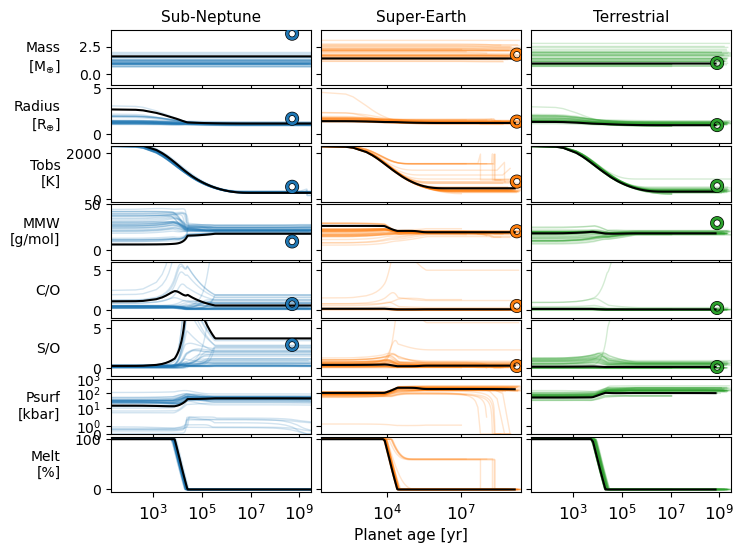

In [97]:
obs = list(bo_data[0]['obs'].keys())
prs = list(bo_data[0]['prs'].keys())
print("Observables:", obs)
print("Parameters:", prs)

obs.extend(['P_surf', 'Phi_global'])


N_obs = len(obs)
N_bo = len(bo_data)

fig,axs = plt.subplots(N_obs,N_bo,figsize=(8,6))


# for each observable
for iax in range(N_obs):
    key = obs[iax]

    scale = 1
    yscl = "linear"
    ylim=None
    ylbl = key
    if key == "M_planet":
        scale = M_earth
        ylim  = [-1, 4]
        ylbl  = "Mass\n" + r"[M$_{\oplus}$]"
    elif key == "R_obs":
        scale = R_earth
        ylim = [-1, 5]
        ylbl  = "Radius\n" + r"[R$_{\oplus}$]"
    elif key == "T_obs":
        scale = 1
        ylim = [-100, 2300.0]
        ylbl  = "Tobs\n" + r"[K]"
    elif key == "atm_kg_per_mol":
        scale = 1e-3
        ylim = [-10, 50]
        ylbl = "MMW\n[g/mol]"
    elif key in ["C/O_atm", "S/O_atm"]:
        scale = 1
        ylim = [-1, 6]
        ylbl = key.split("_")[0]
    elif key == "P_surf":
        scale = 1e3
        ylim = [0, 1e3]
        ylbl = "Psurf\n[kbar]"
        yscl = "symlog"
    elif key == "Phi_global":
        scale = 1e-2
        ylim = [-5, 105.0]
        ylbl = "Melt\n[%]"


    # for each BO run
    for jax  in range(N_bo):

        ax = axs[iax, jax]

        bo = bo_data[jax]
        helps      = bo['helps']
        confs      = bo['confs']
        obs_this   = bo['obs']  # observables for this BO run
        prs_this   = bo['prs']  # parameters ranges for this BO run

        is_constrained = key in obs_this.keys()
        col = bo_cols[jax]

        # plot simulations
        for isim in range(len(helps)):
            help = helps[isim]
            conf = confs[isim]
            x = help['Time']
            y = help[key] / scale

            alp = bo['log'][isim]['y_value'] # value of objective (best=1)
            alp = max(alp, 0.2)

            if bo['log'][isim]['is_best']:
                col_sim = 'k'
                lw_sim = 1.5
                zorder_sim = 5
                alp = 1.0
            else:
                col_sim = col
                lw_sim = 1
                zorder_sim = 1

            ax.plot(x, y, color=col_sim, alpha=alp, linewidth=lw_sim, zorder=zorder_sim)

        # plot truths
        if is_constrained:
            obs_tru = obs_this[key] / scale
            obs_age = bo_truth['params.stop.time.maximum'][jax]
            ax.scatter(obs_age, obs_tru, color='none', edgecolor=col, s=50, zorder=10, lw=2,
                    path_effects=[pe.Stroke(linewidth=3, foreground='k'), pe.Normal()])

        ax.set_xscale("log")
        ax.set_xlim(left=2e1, right=3e9)
        ax.set_ylim(ylim)
        ax.set_yscale(yscl)
        if jax == 0:
            ax.set_ylabel(ylbl, rotation=0, ha='right', va='center', fontsize=10)
            ax.tick_params(axis='y', which='major', labelsize=10)
        else:
            ax.set_yticklabels([])
        if iax == 0:
            ax.set_title(bo_tits[jax], fontsize=11)
        if iax != N_obs - 1:
            ax.set_xticklabels([])


fig.supxlabel("Planet age [yr]", va='top', fontsize=11, y=0.05)
fig.align_ylabels()
fig.subplots_adjust(wspace=0.05, hspace=0.05)

plt.show()